In [20]:
import squidpy as sq
import anndata as adata
import mudata as md
import muon as mu
import scanpy as sc
import matplotlib.pyplot as plt
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

import warnings
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

In [21]:
import zarr
print(zarr.__version__)

3.1.5


In [22]:
adata = sq.datasets.visium_hne_adata()  # H&E-stained Visium section

In [23]:
adata.X = adata.raw.X

In [24]:
adata.obsp['connectivities']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 53328 stored elements and shape (2688, 2688)>

In [25]:
MultimodalAmortizedLDA.setup_anndata(adata, spatial_key="connectivities")

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', '_spatial_graph', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [26]:
import scanpy as sc
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

model = MultimodalAmortizedLDA(
    adata,
    n_inputs_modalities=[adata.n_vars],
    likelihoods=["gamma_poisson"],
    n_topics=10,
    n_hidden=64,
)

print("spatial flag:", model.spatial)                             # should be True
print("use_gcn:", model.module.guide.use_gcn)                     # should be True
print("adjacency set:", model.module.guide.adjacency is not None) # True
print("gcn encoders:", model.module.guide.gcn_encoders is not None)


spatial flag: True
use_gcn: True
adjacency set: True
gcn encoders: True


In [27]:
model.train(
    max_epochs=1000,
    batch_size=adata.n_obs,  # full batch
    train_size=0.8,          # use all cells
    validation_size=0.2,       # no val subset
    log_every_n_steps=1,     # optional
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 1000/1000: 100%|██████████| 1000/1000 [05:01<00:00,  3.52it/s, v_num=1, elbo_val=1.11e+7, elbo_train=4.41e+7]

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 1000/1000: 100%|██████████| 1000/1000 [05:01<00:00,  3.32it/s, v_num=1, elbo_val=1.11e+7, elbo_train=4.41e+7]


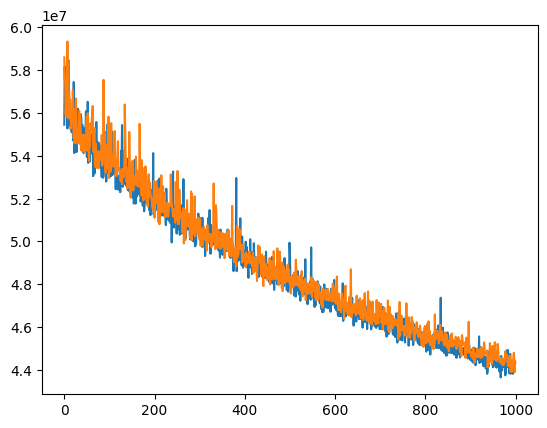

In [28]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*4)

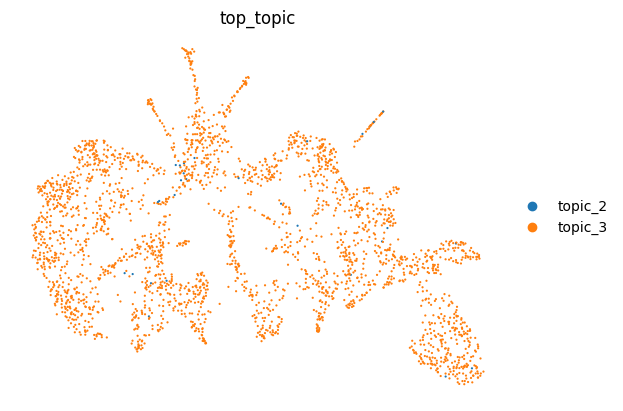

In [29]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

sc.pl.umap(adata, color=["top_topic"], frameon=False, s=10)

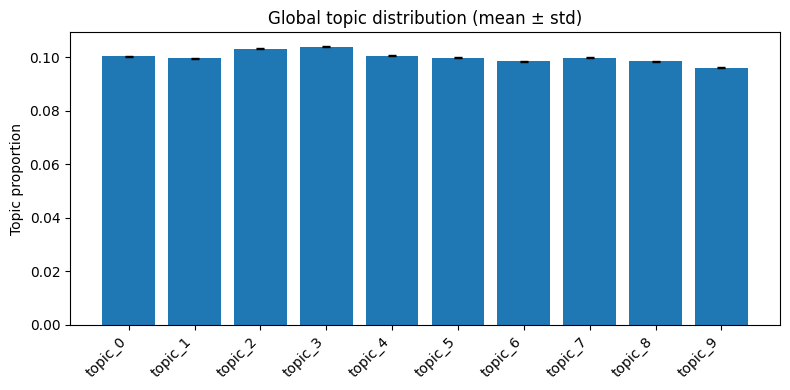

In [30]:
import matplotlib.pyplot as plt
import numpy as np

theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()



##

In [31]:
import scanpy as sc
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

adata_nos = adata.copy()
# remove spatial metadata so spatial flag becomes False
adata_nos.uns.pop("_spatial_graph", None)
adata_nos.uns.pop("_spatial_graphs", None)

# register without spatial_key; keep counts layer if you set it
MultimodalAmortizedLDA.setup_anndata(adata_nos)

model_nos = MultimodalAmortizedLDA(
    adata_nos,
    n_inputs_modalities=[adata_nos.n_vars],
    likelihoods=["gamma_poisson"],
    n_topics=10,
    n_hidden=64,
)

print("spatial flag:", model_nos.spatial)         # False
print("use_gcn:", model_nos.module.guide.use_gcn) # False

model_nos.train(max_epochs=300, batch_size=128, train_size=1.0, validation_size=0, log_every_n_steps=1)

theta_nos = model_nos.get_latent_representation(adata_nos)  # default batching fine



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


spatial flag: False
use_gcn: False
Epoch 300/300: 100%|██████████| 300/300 [05:58<00:00,  1.21s/it, v_num=1, elbo_train=4.42e+7]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 300/300: 100%|██████████| 300/300 [05:58<00:00,  1.19s/it, v_num=1, elbo_train=4.42e+7]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


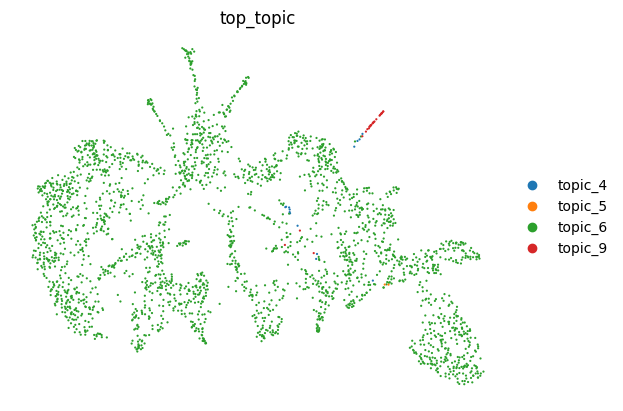

In [32]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model_nos.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

sc.pl.umap(adata, color=["top_topic"], frameon=False, s=10)

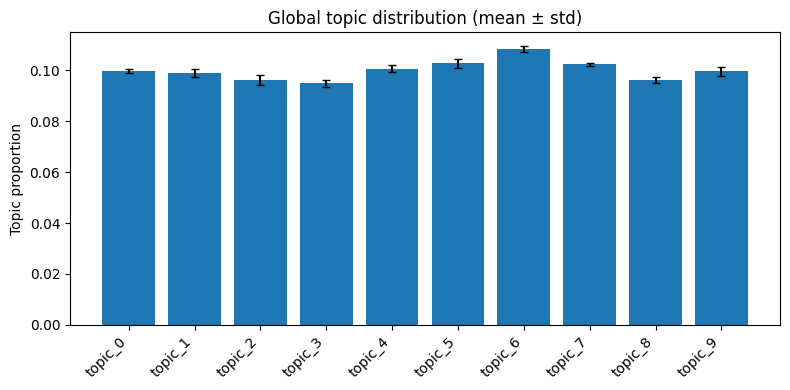

In [33]:
import matplotlib.pyplot as plt
import numpy as np

theta = model_nos.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 30/30: 100%|██████████| 30/30 [00:25<00:00,  1.34it/s, v_num=1, elbo_train=7.57e+8]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [00:25<00:00,  1.16it/s, v_num=1, elbo_train=7.57e+8]
Global topic means:
              gcn      scvi
topic_0  0.092303  0.107993
topic_1  0.092865  0.091263
topic_2  0.100627  0.097493
topic_3  0.099782  0.112082
topic_4  0.110086  0.108150
topic_5  0.091387  0.097546
topic_6  0.102914  0.099184
topic_7  0.108236  0.090478
topic_8  0.094897  0.084382
topic_9  0.106905  0.111428

Topic-wise correlation (by column name match):
topic_0   -0.177445
topic_1    0.149241
topic_2    0.115286
topic_3   -0.178970
topic_4    0.145564
topic_5    0.306439
topic_6    0.040449
topic_7   -0.511812
topic_8   -0.326221
topic_9    0.178034
dtype: float64


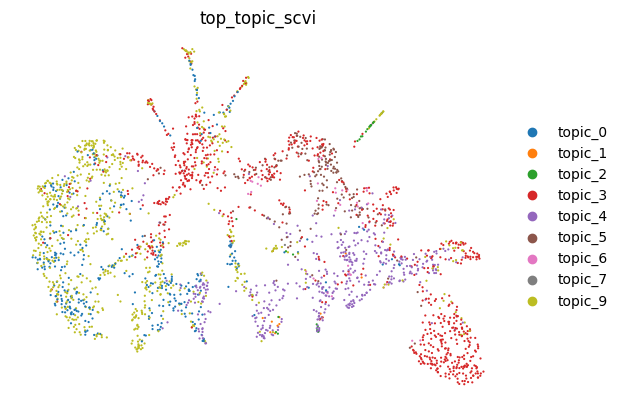

In [15]:
import scanpy as sc
from scvi.model import AmortizedLDA as ScviAmortizedLDA
from topomics.models.amortizedLDA import MultimodalAmortizedLDA

# Assume `adata` already has adata.layers["counts"] with integers
adata_base = adata.copy()
ScviAmortizedLDA.setup_anndata(adata_base)

# Train scvi-tools AmortizedLDA (no spatial support)
scvi_model = ScviAmortizedLDA(adata_base, n_topics=10, n_hidden=64)
scvi_model.train(max_epochs=30, batch_size=128, train_size=1.0, validation_size=0)

theta_scvi = scvi_model.get_latent_representation(adata_base)  # ndarray (cells × topics)

# Your GCN model outputs
theta_gcn = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full-batch for adjacency

# Compare topic means and correlation
import pandas as pd
import numpy as np

df_scvi = pd.DataFrame(theta_scvi, index=adata_base.obs_names, columns=[f"topic_{k}" for k in range(theta_scvi.shape[1])])
df_gcn = theta_gcn  # already DataFrame from your model

print("Global topic means:")
print(pd.DataFrame({"gcn": df_gcn.mean(0), "scvi": df_scvi.mean(0)}))

print("\nTopic-wise correlation (by column name match):")
print(df_gcn.corrwith(df_scvi, axis=0))

# Optional: UMAP of scvi topics
adata_base.obsm["X_topic_scvi"] = df_scvi.values
adata_base.obs["top_topic_scvi"] = df_scvi.idxmax(axis=1)
sc.pl.umap(adata_base, color=["top_topic_scvi"], frameon=False, s=10)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


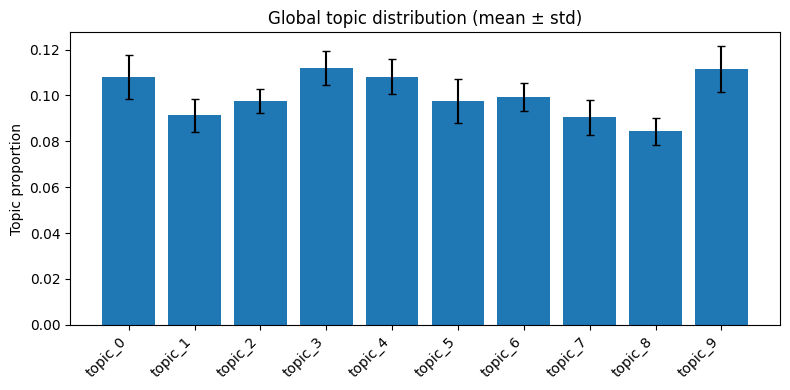

In [16]:
import matplotlib.pyplot as plt
import numpy as np

theta = scvi_model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()